# Presence-mask node churn on a fixed sensor universe

This notebook walks through **fixed-union** node churn: a small sensor network
keeps a stable index universe $N_{\mathrm{max}}$, while individual sensors drop out
and rejoin over time. Presence masks mark whether an entity **exists** at a
timestep; observation masks (shown briefly for contrast) mark whether a
present entity was **measured**.

**Objective.** Fit a graph Koopman model when nodes drop and re-enter, show that
inactive rows do not drive reported mean squared error (MSE), illustrate the
default **hold-last-active** rollout policy, and document the capacity cost of
the fixed-union MVP.

**Prerequisites.** An installed `koopman_graph` environment (CPU is enough).
The cells use short sequences and few epochs so the notebook finishes under
continuous-integration notebook smoke (`nbmake`).

> **Honesty.** This release models churn as presence masks on the existing
> `GraphSnapshotSequence` container (not a parallel entity class). Operator
> matvecs still run at capacity $N_{\mathrm{max}}$ — presence does not shrink the
> linear algebra. Heterogeneous sequences use the same per-type presence
> contract; this tutorial stays homogeneous for clarity. Deferred: unbounded
> growth of the universe and cross-universe index remapping.


## Setup

Imports, seeds, package/torch versions, and plotting defaults. Keep this cell
separate from the narrative so the story below stays readable.


In [1]:
import warnings

from tqdm.std import TqdmExperimentalWarning, TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

import koopman_graph
from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.data import GraphSnapshotSequence
from koopman_graph.losses import masked_mse_loss
from koopman_graph.metrics import evaluate_forecast
from koopman_graph.serialization import build_model_config

SEED = 0
N_MAX = 5
T = 24
IN_CHANNELS = 3
LATENT_DIM = 8
EPOCHS = 12
LR = 1e-2
DEVICE = "cpu"

torch.manual_seed(SEED)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

print("koopman_graph", koopman_graph.__version__)
print("torch", torch.__version__)
print(f"N_max={N_MAX}, T={T}, epochs={EPOCHS}")


koopman_graph 0.11.0
torch 2.13.0
N_max=5, T=24, epochs=12


## Motivation and background

Sensor networks and similar monitoring graphs often keep a **declared roster**
of entities even when some sensors drop offline and later rejoin. Two failure
modes are easy to confuse:

1. **Absence** — the entity is not in the active universe at time $t$ (drop-out /
   re-entry). Scoring its padded row as if it were a real target poisons MSE/MAE.
2. **Partial observation** — the entity still exists, but this timestep was not
   measured. That is an observation-mask problem (see notebooks 17 and 25), not
   node churn.

A naive fixed-cardinality pipeline either rejects variable presence or averages
losses over all $N_{\mathrm{max}}$ rows, so inactive pads dominate error. The package
MVP keeps a fixed index universe and attaches boolean **presence masks**; losses
and `evaluate_forecast` reduce only over present $\land$ observed rows, while
operator matvecs still run at capacity $N_{\mathrm{max}}$.


## Minimal example

Build a path-graph sequence with one mid-window drop-out/re-entry, enable
`allow_node_churn=True`, and inspect the composed loss mask. Inactive feature
rows are padded zeros (conventional, not enforced).


In [2]:
edge_index = torch.tensor(
    [[0, 1, 1, 2, 2, 3, 3, 4], [1, 0, 2, 1, 3, 2, 4, 3]],
    dtype=torch.long,
)
entity_ids = tuple(f"n{i}" for i in range(N_MAX))

presence = torch.ones(T, N_MAX, dtype=torch.bool)
# Drop sensor n4 for timesteps 8..15 inclusive; re-enter from 16 onward.
presence[8:16, -1] = False

x0 = torch.randn(N_MAX, IN_CHANNELS)
features = torch.zeros(T, N_MAX, IN_CHANNELS)
features[0] = x0
for t in range(1, T):
    features[t] = 0.9 * features[t - 1]
    # Conventional zero padding while absent (does not affect masked losses).
    features[t, ~presence[t]] = 0.0

sequence = GraphSnapshotSequence.from_arrays(
    features,
    edge_index,
    presence_masks=presence,
    entity_ids=entity_ids,
    allow_node_churn=True,
)

print(
    "presence False count:",
    int((~presence).sum()),
    "| first absent t:",
    int((~presence[:, -1]).nonzero(as_tuple=False)[0]),
    "| re-entry t:",
    int((presence[8:, -1]).nonzero(as_tuple=False)[0]) + 8,
)
print("loss_mask at t=10 (present ∧ observed):", sequence.loss_mask_at(10).tolist())


presence False count: 8 | first absent t: 8 | re-entry t: 16
loss_mask at t=10 (present ∧ observed): [True, True, True, True, False]


### Presence timeline

The heatmap below is the presence contract: dark cells are absent entities.
Losses and evaluation score only rows that are present (and observed, when
observation masks exist).


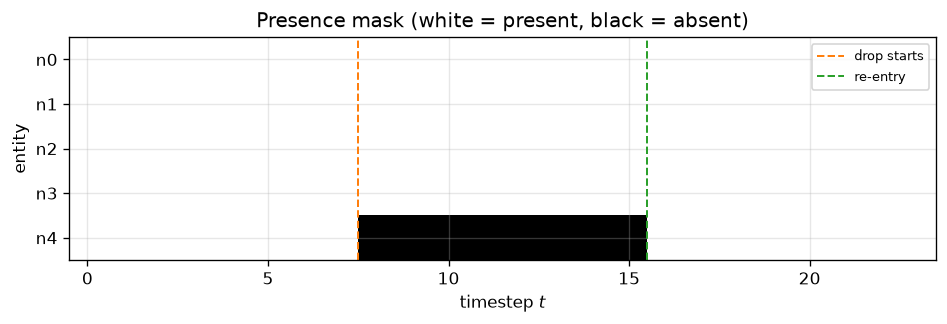

In [3]:
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.imshow(presence.T.numpy(), aspect="auto", interpolation="nearest", cmap="Greys_r")
ax.set_xlabel(r"timestep $t$")
ax.set_ylabel("entity")
ax.set_yticks(range(N_MAX))
ax.set_yticklabels(entity_ids)
ax.set_title("Presence mask (white = present, black = absent)")
# Mark drop and re-entry boundaries for n4.
ax.axvline(7.5, color="C1", ls="--", lw=1.2, label="drop starts")
ax.axvline(15.5, color="C2", ls="--", lw=1.2, label="re-entry")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()


## Progressive deep dive

### Presence versus observation

Presence answers “does the entity exist?” Observation answers “was it
measured?” They compose as present $\land$ observed for loss reductions.
The next cell attaches an observation mask that blinds one *present* sensor
without removing it from the universe.


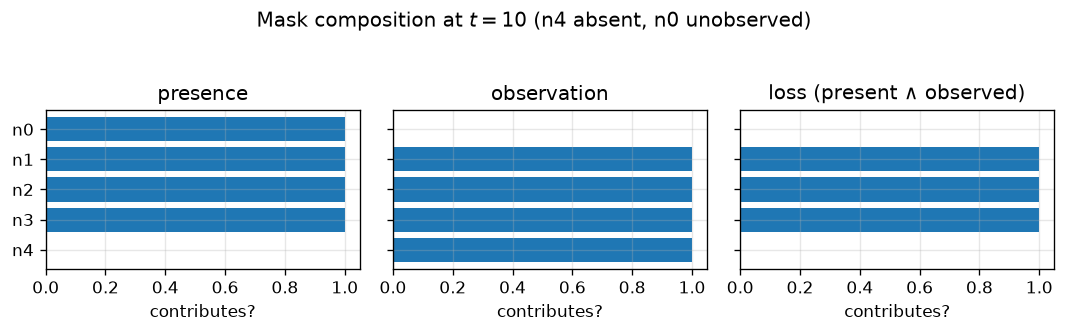

pair_loss_mask(9) excludes nodes absent/unobserved on either side of the pair
[False, True, True, True, False]


In [4]:
observation = torch.ones(T, N_MAX, dtype=torch.bool)
# Blind sensor n0 whenever it is present (still exists in the universe).
observation[:, 0] = False
# Keep the contract valid: at least one observed node each timestep.
observation[:, 1] = True

seq_both = GraphSnapshotSequence.from_arrays(
    features,
    edge_index,
    presence_masks=presence,
    observation_masks=observation,
    entity_ids=entity_ids,
    allow_node_churn=True,
)

t = 10
fig, axes = plt.subplots(1, 3, figsize=(9, 2.6), sharey=True)
for ax, mask, title in zip(
    axes,
    [
        seq_both.presence_mask_at(t),
        seq_both.observation_mask_at(t),
        seq_both.loss_mask_at(t),
    ],
    ["presence", "observation", r"loss (present $\wedge$ observed)"],
    strict=True,
):
    ax.barh(range(N_MAX), mask.float().numpy(), color="C0")
    ax.set_yticks(range(N_MAX))
    ax.set_yticklabels(entity_ids)
    ax.set_xlim(0, 1.05)
    ax.set_title(title)
    ax.set_xlabel("contributes?")
axes[0].invert_yaxis()
fig.suptitle(rf"Mask composition at $t = {t}$ (n4 absent, n0 unobserved)", y=1.05)
fig.tight_layout()
plt.show()

print("pair_loss_mask(9) excludes nodes absent/unobserved on either side of the pair")
print(seq_both.pair_loss_mask(9).tolist())


### Fit under churn

A small GCN encoder/decoder with a per-node Koopman operator trains on the
presence-masked sequence. The fit should complete with finite loss; inactive
rows are excluded from reconstruction and consistency reductions.


final train loss=0.0614  epochs=12


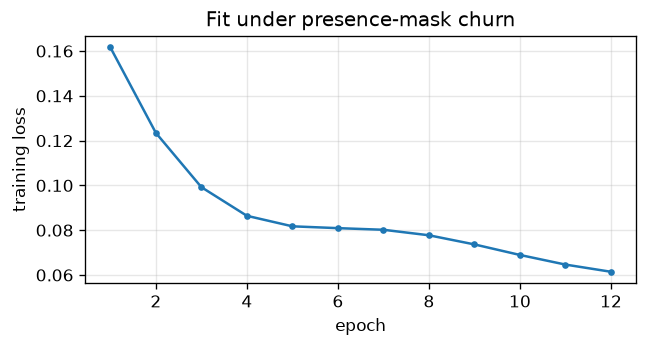

In [5]:
def make_model() -> GraphKoopmanModel:
    torch.manual_seed(SEED)
    return GraphKoopmanModel(
        encoder=GNNEncoder(IN_CHANNELS, 16, LATENT_DIM, num_layers=1),
        decoder=GNNDecoder(LATENT_DIM, 16, IN_CHANNELS, num_layers=1),
        latent_dim=LATENT_DIM,
        time_step=1.0,
    )


model = make_model()
history = model.fit(sequence, epochs=EPOCHS, lr=LR, device=DEVICE)
print(
    f"final train loss={history.loss[-1]:.4f}  epochs={history.epochs}"
)

fig, ax = plt.subplots(figsize=(5.5, 3.0))
ax.plot(range(1, len(history.loss) + 1), history.loss, marker="o", ms=3)
ax.set_xlabel("epoch")
ax.set_ylabel("training loss")
ax.set_title("Fit under presence-mask churn")
fig.tight_layout()
plt.show()


## Results

Three checks follow: (1) inactive-row poison leaves masked MSE/MAE unchanged,
(2) rollout **holds** the last active state while a node is absent, and
(3) present cardinality can drop below $N_{\mathrm{max}}$ while matvec width does not.
Look for equal masked clean/poison bars, a flat `n4` norm through the shaded
absence window, and a present-count step below the capacity line.


### Quantitative masked-MSE effect

Poison inactive feature rows at evaluation time. If losses incorrectly average
over $N_{\mathrm{max}}$ instead of contributing rows, MSE/MAE explode. With the
composed present $\land$ observed contract, metrics stay near the clean baseline.

We also compare an **unmasked** MSE on the same poisoned target to show the
gap the mask closes.


masked MSE (clean target):   0.030463
masked MSE (poisoned inactive): 0.030463
unmasked MSE (poisoned):     2.000e+11
evaluate_forecast MAE clean : {1: 0.364065, 2: 0.411127}
evaluate_forecast MAE poison: {1: 0.364065, 2: 0.411127}


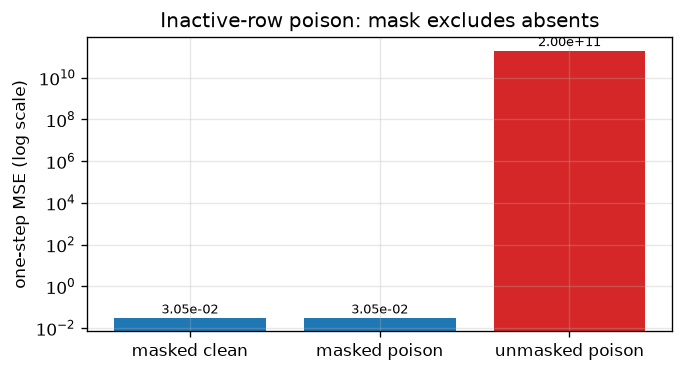

In [6]:
# Poison inactive rows on a copy used only for scoring demos.
poisoned_snaps = [snap.clone() for snap in sequence.snapshots]
for t in range(T):
    if not bool(presence[t].all()):
        x = poisoned_snaps[t].x.clone()
        x[~presence[t]] = 1.0e6
        poisoned_snaps[t].x = x

poisoned = GraphSnapshotSequence(
    poisoned_snaps,
    presence_masks=presence,
    entity_ids=entity_ids,
    allow_node_churn=True,
)

model.eval()
t_src = 9  # pair (9, 10): target has n4 absent
with torch.no_grad():
    pred = model(sequence[t_src])
    target_clean = sequence[t_src + 1].x
    target_poison = poisoned[t_src + 1].x
    mask = sequence.loss_mask_at(t_src + 1)
    assert mask is not None

    mse_masked_clean = float(masked_mse_loss(pred, target_clean, mask))
    mse_masked_poison = float(masked_mse_loss(pred, target_poison, mask))
    mse_unmasked_poison = float(F.mse_loss(pred, target_poison))

print(f"masked MSE (clean target):   {mse_masked_clean:.6f}")
print(f"masked MSE (poisoned inactive): {mse_masked_poison:.6f}")
print(f"unmasked MSE (poisoned):     {mse_unmasked_poison:.3e}")
assert abs(mse_masked_clean - mse_masked_poison) < 1e-5
assert mse_unmasked_poison > 1e3

# Multi-step evaluate_forecast also honors presence via loss_mask_at.
clean_eval = evaluate_forecast(model, sequence, horizons=(1, 2), start_indices=(0, 4))
poison_eval = evaluate_forecast(model, poisoned, horizons=(1, 2), start_indices=(0, 4))
clean_mae = {h.horizon: h.mae for h in clean_eval.horizons}
poison_mae = {h.horizon: h.mae for h in poison_eval.horizons}
print("evaluate_forecast MAE clean :", {k: round(v, 6) for k, v in clean_mae.items()})
print("evaluate_forecast MAE poison:", {k: round(v, 6) for k, v in poison_mae.items()})
for h in clean_mae:
    assert abs(clean_mae[h] - poison_mae[h]) < 1e-4

labels = ["masked clean", "masked poison", "unmasked poison"]
values = [mse_masked_clean, mse_masked_poison, mse_unmasked_poison]
fig, ax = plt.subplots(figsize=(5.8, 3.2))
bars = ax.bar(labels, values, color=["C0", "C0", "C3"])
ax.set_yscale("log")
ax.set_ylabel("one-step MSE (log scale)")
ax.set_title("Inactive-row poison: mask excludes absents")
for bar, val in zip(bars, values, strict=True):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val * 1.15,
        f"{val:.2e}",
        ha="center",
        va="bottom",
        fontsize=8,
    )
fig.tight_layout()
plt.show()


### Rollout policy: hold last active state

While a node is absent, `predict` with `future_presence` **holds** the last
active latent/feature row rather than zeroing it. On re-entry the held state
resumes advancing. Matvecs still use all $N_{\mathrm{max}}$ rows — the hold is a
state policy, not a sparsity optimization.


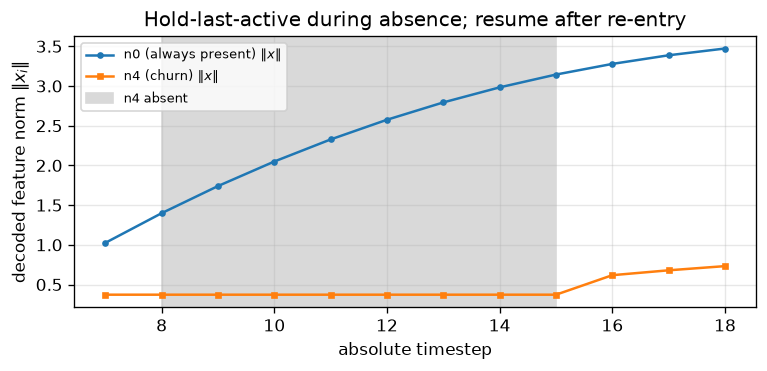

held n4 norms at first two absent predict steps: 0.37236812710762024 0.37236812710762024 diff 0.0


In [7]:
origin_t = 6  # present; next steps include absence then re-entry
horizon = 12
future_presence = presence[origin_t + 1 : origin_t + 1 + horizon]
assert future_presence.shape == (horizon, N_MAX)

preds = model.predict(
    sequence[origin_t],
    steps=horizon,
    future_presence=future_presence,
)

held = []
active = []
for step, snap in enumerate(preds, start=1):
    t = origin_t + step
    held.append(float(snap.x[-1].norm()))
    active.append(float(snap.x[0].norm()))

fig, ax = plt.subplots(figsize=(6.5, 3.2))
times = list(range(origin_t + 1, origin_t + 1 + horizon))
ax.plot(times, active, marker="o", ms=3, label=r"n0 (always present) $\|x\|$")
ax.plot(times, held, marker="s", ms=3, label=r"n4 (churn) $\|x\|$")
ax.axvspan(8, 15, color="0.85", label="n4 absent")
ax.set_xlabel("absolute timestep")
ax.set_ylabel(r"decoded feature norm $\|x_i\|$")
ax.set_title("Hold-last-active during absence; resume after re-entry")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# During absence, consecutive held norms for n4 should match (frozen decode).
absent_steps = [i for i, t in enumerate(times) if 8 <= t <= 15]
if len(absent_steps) >= 2:
    a, b = absent_steps[0], absent_steps[1]
    print(
        "held n4 norms at first two absent predict steps:",
        held[a],
        held[b],
        "diff",
        abs(held[a] - held[b]),
    )


### Fixed-union capacity cost

Even when only four sensors are present, the model allocates and multiplies
through five latent rows. Presence masks change **which rows contribute to
loss and metrics**, not the asymptotic matvec cost. That is the deliberate
MVP tradeoff: simple indexing and DDP/window alignment at the price of
carrying inactive capacity.


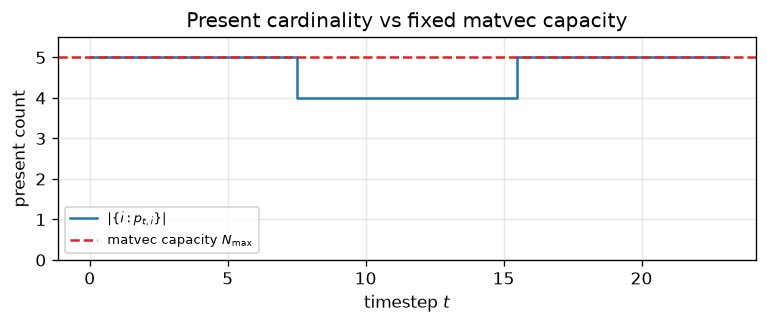

min present=4, max present=5, N_max=5 (always the operator width)


In [8]:
present_counts = presence.sum(dim=1).tolist()
fig, ax = plt.subplots(figsize=(6.5, 2.8))
ax.step(range(T), present_counts, where="mid", color="C0", label=r"$|\{i: p_{t,i}\}|$")
ax.axhline(N_MAX, color="C3", ls="--", label=r"matvec capacity $N_{\mathrm{max}}$")
ax.set_ylim(0, N_MAX + 0.5)
ax.set_xlabel(r"timestep $t$")
ax.set_ylabel("present count")
ax.set_title("Present cardinality vs fixed matvec capacity")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(
    f"min present={min(present_counts)}, max present={max(present_counts)}, "
    f"N_max={N_MAX} (always the operator width)"
)


### Checkpoint contract (flags, not presence tensors)

`fit` stamps the churn contract onto the model. `build_model_config` records
`allow_node_churn`, `has_presence_masks`, and optional `entity_ids`. Presence
mask **tensors** stay with the sequence data and are **not** stored in the
checkpoint — reload them with the evaluate / continue-training sequence.


In [9]:
assert model.allow_node_churn
assert model.has_presence_masks
assert model.entity_ids == entity_ids

config = build_model_config(model)
print(
    {
        "allow_node_churn": config["allow_node_churn"],
        "has_presence_masks": config["has_presence_masks"],
        "entity_ids": config.get("entity_ids"),
    }
)
assert "presence_masks" not in config


{'allow_node_churn': True, 'has_presence_masks': True, 'entity_ids': ['n0', 'n1', 'n2', 'n3', 'n4']}


## Interpretation / discussion

The results close the motivation gap: presence masks stop inactive pads from
driving reported error, while observation masks remain the right tool for
measurement gaps on entities that still exist. Hold-last-active is a state
policy for re-entry continuity; it does not buy sparse linear algebra.

Tradeoffs versus alternatives are explicit. Zeroing absent rows (instead of
holding) would discard re-entry memory. Dynamic graph libraries that grow and
shrink node sets avoid the capacity tax but forfeit the fixed-index MVP that
keeps DDP windows and checkpoint row order simple. Until open-world growth and
cross-universe remapping land, treat $N_{\mathrm{max}}$ as a declared capacity for a
closed sensor roster and keep `entity_ids` stable across train and evaluate
sequences.

**Deferred cases (open world).** This MVP does **not** cover:

1. **Unbounded growth** — adding entities beyond a predeclared $N_{\mathrm{max}}$
   without rebuilding the universe / remapping indices.
2. **Cross-universe remapping** — aligning two sequences whose entity id sets
   differ (train on sensors A–E, evaluate on B–F with a different row order).
3. **Heterogeneous hold / evaluate presence** — per-type presence masks exist
   for training losses; homo-style `future_presence` hold on hetero predict
   and hetero `entity_ids` remain follow-ups.


## Takeaways

- Use `presence_masks` + `allow_node_churn=True` for fixed-union drop-in/out;
  do not overload `observation_masks` for absence.
- Training and `evaluate_forecast` score present $\land$ observed rows only;
  poisoned inactive targets do not change masked MSE/MAE.
- Rollout defaults to **hold last active** under `future_presence`.
- Cost honesty: linear algebra still runs at $N_{\mathrm{max}}$.
- When **not** to use this MVP: unbounded roster growth, or train/eval universes
  that need index remapping — rebuild / align ids first.
- Checkpoint metadata records churn flags and optional `entity_ids` after `fit`;
  presence tensors stay with the sequence (not in the checkpoint config).


## Further reading

- Sphinx data guide — presence vs observation masks:
  [`docs/source/data.rst`](../docs/source/data.rst) (section “Presence masks vs
  observation masks”)
- Limitations — fixed-union churn / open-world boundaries:
  [`docs/source/limitations.rst`](../docs/source/limitations.rst)
- Related notebooks:
  [`17_delay_embedding_partial_observability.ipynb`](17_delay_embedding_partial_observability.ipynb)
  (observation masks / delays),
  [`25_kalman_koopman_state_estimation.ipynb`](25_kalman_koopman_state_estimation.ipynb)
  (imputation under observation masks)
- API: `koopman_graph.data.GraphSnapshotSequence`
  (`loss_mask_at`, `pair_loss_mask`, `presence_masks`, `allow_node_churn`),
  `koopman_graph.losses.masked_mse_loss`,
  `koopman_graph.metrics.evaluate_forecast`,
  `GraphKoopmanModel.predict(..., future_presence=...)`,
  `koopman_graph.serialization.build_model_config`
